# Natural Language Processing Task
## 6CS012 – Final Integrated Assessment | Part III: WordsTasks
**Herald College Kathmandu | Artificial Intelligence and Machine Learning**

---
Name : Niroj Khatri

Uni id :2431487

section: L6CG22
---

In [1]:
!pip install numpy gensim nltk
!pip install gensim
!pip install nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 61.2 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, SimpleRNN, LSTM
from tensorflow.keras.callbacks import EarlyStopping

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer


In [4]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [5]:
df = pd.read_csv("/content/drive/MyDrive/portfolio/Hotel_Reviews.csv")

# Use review + label (adjust column names if needed)
df = df[['Review', 'Rating']]

# Convert rating to sentiment (binary)
df['sentiment'] = df['Rating'].apply(lambda x: 1 if x >= 3 else 0)

df.head()

,Review,Rating,sentiment
0,nice hotel expensive parking got good deal sta...,4,1
1,ok nothing special charge diamond member hilto...,2,0
2,nice rooms not 4* experience hotel monaco seat...,3,1
3,"unique, great stay, wonderful time hotel monac...",5,1
4,"great stay great stay, went seahawk game aweso...",5,1


In [6]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)

    words = text.split()
    words = [w for w in words if w not in stop_words]
    words = [lemmatizer.lemmatize(w) for w in words]

    return " ".join(words)

df['cleaned'] = df['Review'].apply(clean_text)

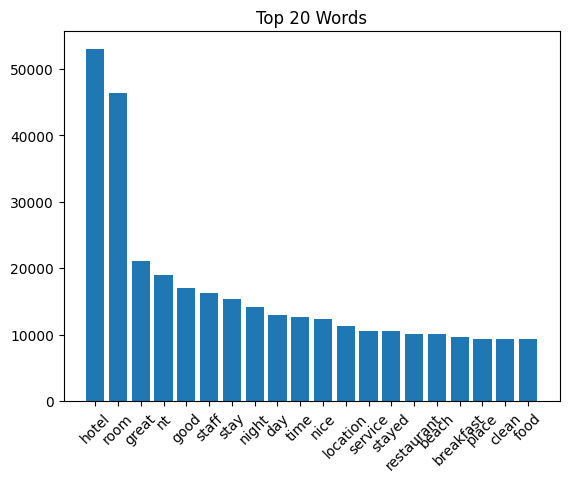

In [7]:
from collections import Counter

all_words = " ".join(df['cleaned']).split()
word_counts = Counter(all_words)

common_words = word_counts.most_common(20)
words, counts = zip(*common_words)

plt.figure()
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top 20 Words")
plt.show()

In [8]:
X = df['cleaned']
y = df['sentiment']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Tokenizer
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Padding
max_len = 100
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

In [9]:
model_rnn = Sequential()
model_rnn.add(Embedding(input_dim=5000, output_dim=64, input_length=max_len))
model_rnn.add(SimpleRNN(64))
model_rnn.add(Dense(1, activation='sigmoid'))

model_rnn.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

history_rnn = model_rnn.fit(
    X_train_pad, y_train,
    validation_data=(X_test_pad, y_test),
    epochs=5,
    callbacks=[EarlyStopping(patience=2)]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/5
513/513 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.8463 - loss: 0.4118 - val_accuracy: 0.8778 - val_loss: 0.3174
Epoch 2/5
513/513 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9032 - loss: 0.2503 - val_accuracy: 0.8853 - val_loss: 0.3026
Epoch 3/5
513/513 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9535 - loss: 0.1310 - val_accuracy: 0.8800 - val_loss: 0.3493
Epoch 4/5
513/513 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9801 - loss: 0.0593 - val_accuracy: 0.8236 - val_loss: 0.5069


In [10]:
model_lstm = Sequential()
model_lstm.add(Embedding(input_dim=5000, output_dim=64, input_length=max_len))
model_lstm.add(LSTM(64))
model_lstm.add(Dense(1, activation='sigmoid'))

model_lstm.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

history_lstm = model_lstm.fit(
    X_train_pad, y_train,
    validation_data=(X_test_pad, y_test),
    epochs=5,
    callbacks=[EarlyStopping(patience=2)]
)

Epoch 1/5
513/513 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.8938 - loss: 0.2727 - val_accuracy: 0.9100 - val_loss: 0.2623
Epoch 2/5
513/513 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9402 - loss: 0.1578 - val_accuracy: 0.9163 - val_loss: 0.2514
Epoch 3/5
513/513 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9578 - loss: 0.1161 - val_accuracy: 0.9112 - val_loss: 0.2834
Epoch 4/5
513/513 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9686 - loss: 0.0877 - val_accuracy: 0.9080 - val_loss: 0.3037


In [11]:
import gensim.downloader as api

embedding_model = api.load('glove-wiki-gigaword-50')

word_index = tokenizer.word_index
embedding_dim = 50

embedding_matrix = np.zeros((5000, embedding_dim))

for word, i in word_index.items():
    if i < 5000 and word in embedding_model:
        embedding_matrix[i] = embedding_model[word]

model_w2v = Sequential()
model_w2v.add(Embedding(
    input_dim=5000,
    output_dim=embedding_dim,
    weights=[embedding_matrix],
    input_length=max_len,
    trainable=False
))
model_w2v.add(LSTM(64))
model_w2v.add(Dense(1, activation='sigmoid'))

model_w2v.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

history_w2v = model_w2v.fit(
    X_train_pad, y_train,
    validation_data=(X_test_pad, y_test),
    epochs=5,
    callbacks=[EarlyStopping(patience=2)]
)

[==================================================] 100.0% 66.0/66.0MB downloaded
Epoch 1/5
513/513 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.8640 - loss: 0.3305 - val_accuracy: 0.8856 - val_loss: 0.2706
Epoch 2/5
513/513 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9022 - loss: 0.2406 - val_accuracy: 0.9044 - val_loss: 0.2443
Epoch 3/5
513/513 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9104 - loss: 0.2160 - val_accuracy: 0.9010 - val_loss: 0.2524
Epoch 4/5
513/513 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9150 - loss: 0.2034 - val_accuracy: 0.8970 - val_loss: 0.2317
Epoch 5/5
513/513 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9210 - loss: 0.1912 - val_accuracy: 0.9102 - val_loss: 0.2264


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

def evaluate(model, X_test, y_test, model_name):
    preds = (model.predict(X_test) > 0.5).astype(int)

    # Generate Confusion Matrix
    cm = confusion_matrix(y_test, preds)

    # Plot Interactive Confusion Matrix using Plotly
    fig = go.Figure(data=go.Heatmap(
        z=cm,
        x=['Negative', 'Positive'],
        y=['Negative', 'Positive'],
        colorscale='Blues',
        hoverongaps=False,
        text=cm, # Display numbers on the heatmap
        texttemplate="%{text}",
        textfont={"size":16}
    ))
    fig.update_layout(
        title=f'Confusion Matrix for {model_name}',
        xaxis_title='Predicted Label',
        yaxis_title='True Label',
        xaxis_nticks=2, # Ensure only 'Negative' and 'Positive' are shown
        yaxis_nticks=2
    )
    fig.show()

    print(f"Classification Report for {model_name}:")
    print(classification_report(y_test, preds))

print("RNN:")
evaluate(model_rnn, X_test_pad, y_test, "RNN")

print("LSTM:")
evaluate(model_lstm, X_test_pad, y_test, "LSTM")

print("LSTM + Word2Vec:")
evaluate(model_w2v, X_test_pad, y_test, "LSTM + Word2Vec")

RNN:
129/129 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


Classification Report for RNN:
              precision    recall  f1-score   support

           0       0.41      0.25      0.31       652
           1       0.87      0.93      0.90      3447

    accuracy                           0.82      4099
   macro avg       0.64      0.59      0.61      4099
weighted avg       0.80      0.82      0.81      4099

LSTM:
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


Classification Report for LSTM:
              precision    recall  f1-score   support

           0       0.79      0.58      0.67       652
           1       0.92      0.97      0.95      3447

    accuracy                           0.91      4099
   macro avg       0.86      0.77      0.81      4099
weighted avg       0.90      0.91      0.90      4099

LSTM + Word2Vec:
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


Classification Report for LSTM + Word2Vec:
              precision    recall  f1-score   support

           0       0.78      0.61      0.68       652
           1       0.93      0.97      0.95      3447

    accuracy                           0.91      4099
   macro avg       0.85      0.79      0.82      4099
weighted avg       0.91      0.91      0.91      4099



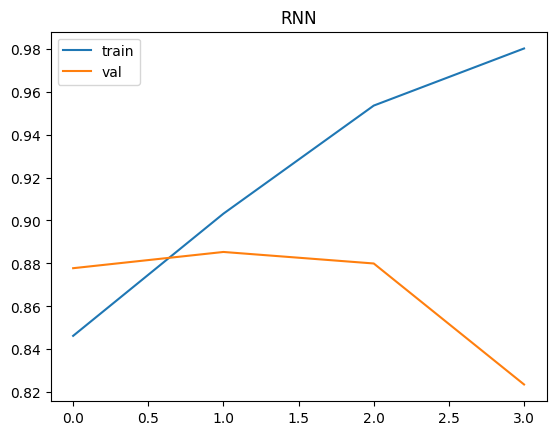

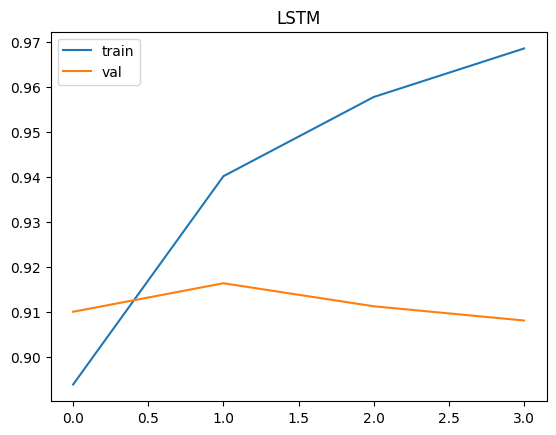

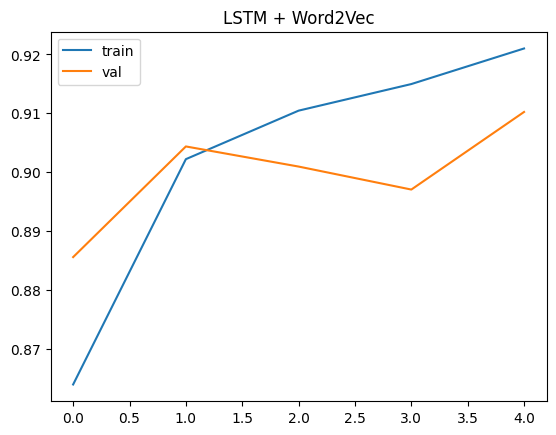

In [13]:
def plot_history(history, title):
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(title)
    plt.legend(['train', 'val'])
    plt.show()

plot_history(history_rnn, "RNN")
plot_history(history_lstm, "LSTM")
plot_history(history_w2v, "LSTM + Word2Vec")

In [14]:
preds = (model_w2v.predict(X_test_pad) > 0.5).astype(int)

for i in range(10):
    if preds[i] != y_test.iloc[i]:
        print("TEXT:", X_test.iloc[i])
        print("TRUE:", y_test.iloc[i], "PRED:", preds[i][0])
        print("-"*50)

129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
TEXT: need tender loving care recently stayed biltmore boyfriend corporate retreat ground expansive little confusing actually got lost time way hotel room amenity enjoyed service spa fine tennis great try jas best instructor golf course great disappointed room serviceour room original cottage little thing annoying scuffed wall peeling paint ceiling shower biggest problem bug big cockroach unidentified bug day thre gap door moved new suite wastebasket littered dirty qtips arrived nt company paying nt complain upset stayed dime esp conferencesgroups meeting big loud party
TRUE: 1 PRED: 0
--------------------------------------------------
TEXT: ca nt xd stayed night cellai feb payed euro night called classic room obviously little bit larger average room bathroom tinywe reservation directly hotel website week advanceour room wasnt really clean dark roof light noisy tv tiny working properly ac heat roombreakfast finefree bike rental internet point av

In [15]:
import gradio as gr

In [16]:
def predict_sentiment(text):
    # Clean the input text using the same clean_text function
    cleaned_text = clean_text(text)

    # Tokenize the cleaned text
    seq = tokenizer.texts_to_sequences([cleaned_text])

    # Pad the sequence to the same max_len used during training
    padded_seq = pad_sequences(seq, maxlen=max_len)

    # Predict sentiment using the trained model (model_w2v)
    prediction = model_w2v.predict(padded_seq)[0][0]

    # Convert probability to sentiment label
    if prediction >= 0.5:
        return f"Positive (Confidence: {prediction:.2f})"
    else:
        return f"Negative (Confidence: {1 - prediction:.2f})"

In [ ]:
iface = gr.Interface(
    fn=predict_sentiment,
    inputs=gr.Textbox(lines=5, placeholder="Enter your hotel review here..."),
    outputs="text",
    title="Hotel Review Sentiment Predictor",
    description="Enter a hotel review and get its predicted sentiment (Positive/Negative)."
)

iface.launch(debug=True)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://ed6f450c0968c3a6ce.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Created dataset file at: .gradio/flagged/dataset1.csv
